In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from pathlib import Path
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from skimage.feature import hog
from skimage import feature,data, exposure

from scipy.stats import skew
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

In [2]:
def get_original_image(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    return img

def get_gray_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img / 255.0
    return img
    
def get_pixel_mean(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.mean()
    
def get_pixel_std(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.std()

def get_pixel_min(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.min()

def get_pixel_max(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.max()

def get_pixel_median(path):
    img = cv2.imread(path)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return np.median(img)

def get_hog_features(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (256, 256))
    imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog = feature.hog(imgGray, pixels_per_cell=(8,8),
                          cells_per_block=(2,2), visualize=False)
    return hog

    
def displayheatmap(cm):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,        # show numbers
        fmt="d",           # integer format
        cmap="Blues",      # color map
        cbar=False
    )
    
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")
    plt.show()


In [13]:
df.describe()

,file_size,label,img_mean,img_std,img_min,img_max,img_median
count,1.017000e+03,1017.000000,1017.000000,1017.000000,1017.000000,1017.000000,1017.000000
mean,1.047672e+06,0.259587,136.559603,68.498404,16.952802,253.608653,127.963618
std,3.362889e+05,0.438624,29.060013,15.565429,6.456223,4.237098,52.649820
min,4.885690e+05,0.000000,86.417737,45.903220,4.000000,230.000000,76.000000
25%,5.420760e+05,0.000000,105.371048,55.336097,13.000000,255.000000,88.000000
50%,1.158617e+06,0.000000,137.312217,64.287795,15.000000,255.000000,93.000000
75%,1.340431e+06,1.000000,170.324772,91.249114,25.000000,255.000000,199.000000
max,1.421426e+06,1.000000,187.889085,93.904088,30.000000,255.000000,219.000000


In [3]:
#image_files = list(Path(f"../Projects/mvtec_anomaly_detection/").rglob("*"))
#image_files = list(Path(f"C:/Kavitha/DataScientest/Projects/Test").rglob("*"))
image_files = list(Path(f"C:/Kavitha/DataScientest/Projects/Test_toothbrush").rglob("*"))
image_files = [f for f in image_files if f.is_file() and f.suffix.lower() in ('.png','.jpg','jpeg','.gif') and f.parent.parent.name != 'ground_truth']

#print(len(image_files))
#print(image_files[10])
#print(os.path.dirname(image_files[100]))
#print(os.path.basename(os.path.dirname(image_files[100])))

df = pd.DataFrame({
    "file_path": image_files,
    "category_name": [f.parent.parent.parent.name for f in image_files],
    "dir_name": [f.parent.name for f in image_files],
    "file_name": [f.name for f in image_files],     
    "file_size": [f.stat().st_size for f in image_files],
    "label":  [0 if f.parent.name == "good" else 1 for f in image_files],
    "img_mean": [get_pixel_mean(f) for f in image_files],    
    "img_std": [get_pixel_std(f) for f in image_files],  
    "img_min": [get_pixel_min(f) for f in image_files] , 
    "img_max": [get_pixel_max(f) for f in image_files], 
    "img_median": [get_pixel_median(f) for f in image_files] , 
    "img": [get_original_image(f) for f in image_files],
})


In [4]:
df.to_pickle("df_imageProperties.pkl")
df = pd.read_pickle("df_imageProperties.pkl")

In [13]:
df_loaded = pd.read_pickle("df_imageProperties.pkl")
df_loaded

,file_path,category_name,dir_name,file_name,file_size,label,img_mean,img_std,img_min,img_max,img_median,img
0,C:\Kavitha\DataScientest\Projects\Test\bottle\...,bottle,broken_large,000.png,526002,1,139.371306,91.247824,27,255,91.0,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
1,C:\Kavitha\DataScientest\Projects\Test\bottle\...,bottle,broken_large,001.png,525657,1,135.829478,92.323131,25,255,86.0,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
2,C:\Kavitha\DataScientest\Projects\Test\bottle\...,bottle,broken_large,002.png,515614,1,136.881942,91.297588,29,255,86.0,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
3,C:\Kavitha\DataScientest\Projects\Test\bottle\...,bottle,broken_large,003.png,488569,1,134.391531,93.904088,27,255,80.0,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
4,C:\Kavitha\DataScientest\Projects\Test\bottle\...,bottle,broken_large,004.png,549987,1,138.992403,91.084809,27,255,91.0,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1012,C:\Kavitha\DataScientest\Projects\Test\capsule...,capsule,good,214.png,1165745,0,171.474576,64.405577,14,255,200.0,"[[[230, 226, 227], [228, 224, 223], [228, 226,..."
1013,C:\Kavitha\DataScientest\Projects\Test\capsule...,capsule,good,215.png,1145671,0,172.942948,65.959415,13,255,202.0,"[[[232, 233, 233], [230, 229, 227], [231, 231,..."
1014,C:\Kavitha\DataScientest\Projects\Test\capsule...,capsule,good,216.png,1171192,0,172.303621,65.775501,13,255,201.0,"[[[235, 231, 226], [230, 230, 228], [251, 234,..."
1015,C:\Kavitha\DataScientest\Projects\Test\capsule...,capsule,good,217.png,1158617,0,172.520573,65.594889,14,255,202.0,"[[[228, 228, 231], [227, 225, 225], [222, 229,..."


In [7]:

X = df.select_dtypes(include='number')
X= X.drop('label', axis=1)
y= df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
'''

# Predicting with hog features
X= pd.DataFrame(df['hog'].tolist())
y= df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
'''
X = df.select_dtypes(include='number')
X= X.drop('label', axis=1)
y= df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)

,file_size,img_mean,img_std,img_min,img_max,img_median
322,1326950,102.962413,56.365407,14,255,94.0
202,536779,137.086999,91.573744,27,255,89.0
240,532677,139.525286,91.873828,27,255,91.0
728,1148876,170.096533,64.910222,12,254,199.0
594,1350513,104.711699,54.108994,13,255,92.0
...,...,...,...,...,...,...
12,537890,140.298988,90.559464,29,255,91.0
1009,1120941,162.364141,61.549298,10,233,191.0
324,1313425,98.607256,45.903220,14,255,91.0
924,1132976,171.292079,63.600328,16,247,200.0


0.7847478474784748
0.7401960784313726
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       151
           1       0.50      0.26      0.35        53

    accuracy                           0.74       204
   macro avg       0.64      0.59      0.59       204
weighted avg       0.71      0.74      0.71       204



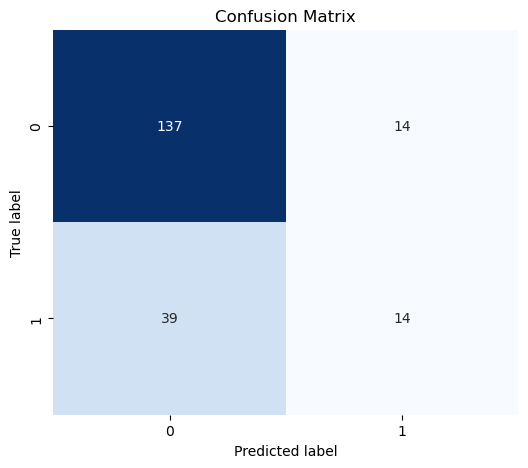

In [8]:
#knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski')
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print(knn.score(X_train, y_train))
y_pred = knn.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
#print(classification_report_imbalanced(y_test, y_pred))
cm= confusion_matrix(y_test,y_pred)
displayheatmap(cm)

0.7404674046740467
0.7401960784313726
              precision    recall  f1-score   support

           0       0.74      1.00      0.85       151
           1       0.00      0.00      0.00        53

    accuracy                           0.74       204
   macro avg       0.37      0.50      0.43       204
weighted avg       0.55      0.74      0.63       204



C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

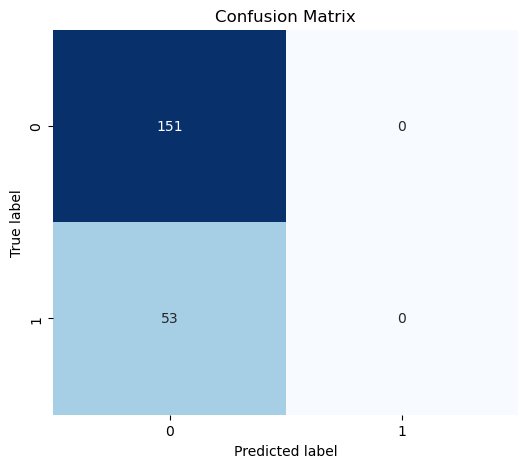

In [9]:
#svm = SVC(gamma=0.01,  kernel='poly')
svm = SVC()
svm.fit(X_train, y_train)
print(svm.score(X_train, y_train))
y_pred = svm.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test,y_pred)
displayheatmap(cm)

1.0
0.8529411764705882
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       151
           1       0.79      0.58      0.67        53

    accuracy                           0.85       204
   macro avg       0.83      0.77      0.79       204
weighted avg       0.85      0.85      0.85       204



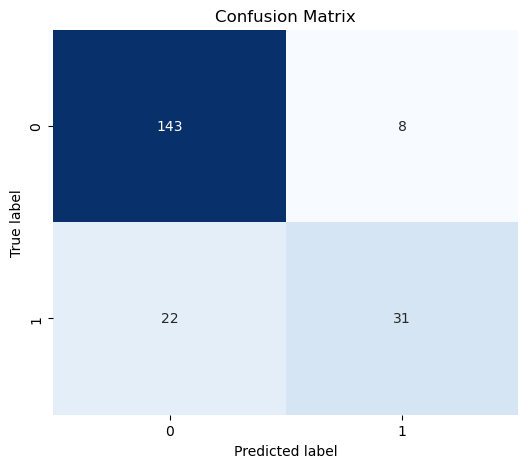

Significant features impacting prediction
img_mean      0.244798
img_std       0.237401
file_size     0.223937
img_median    0.129719
img_min       0.124948
img_max       0.039196
dtype: float64


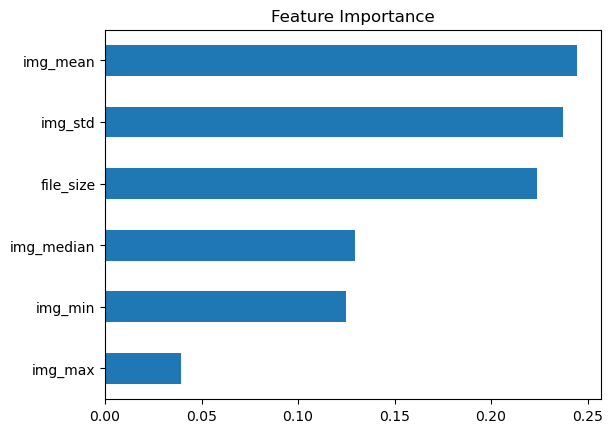

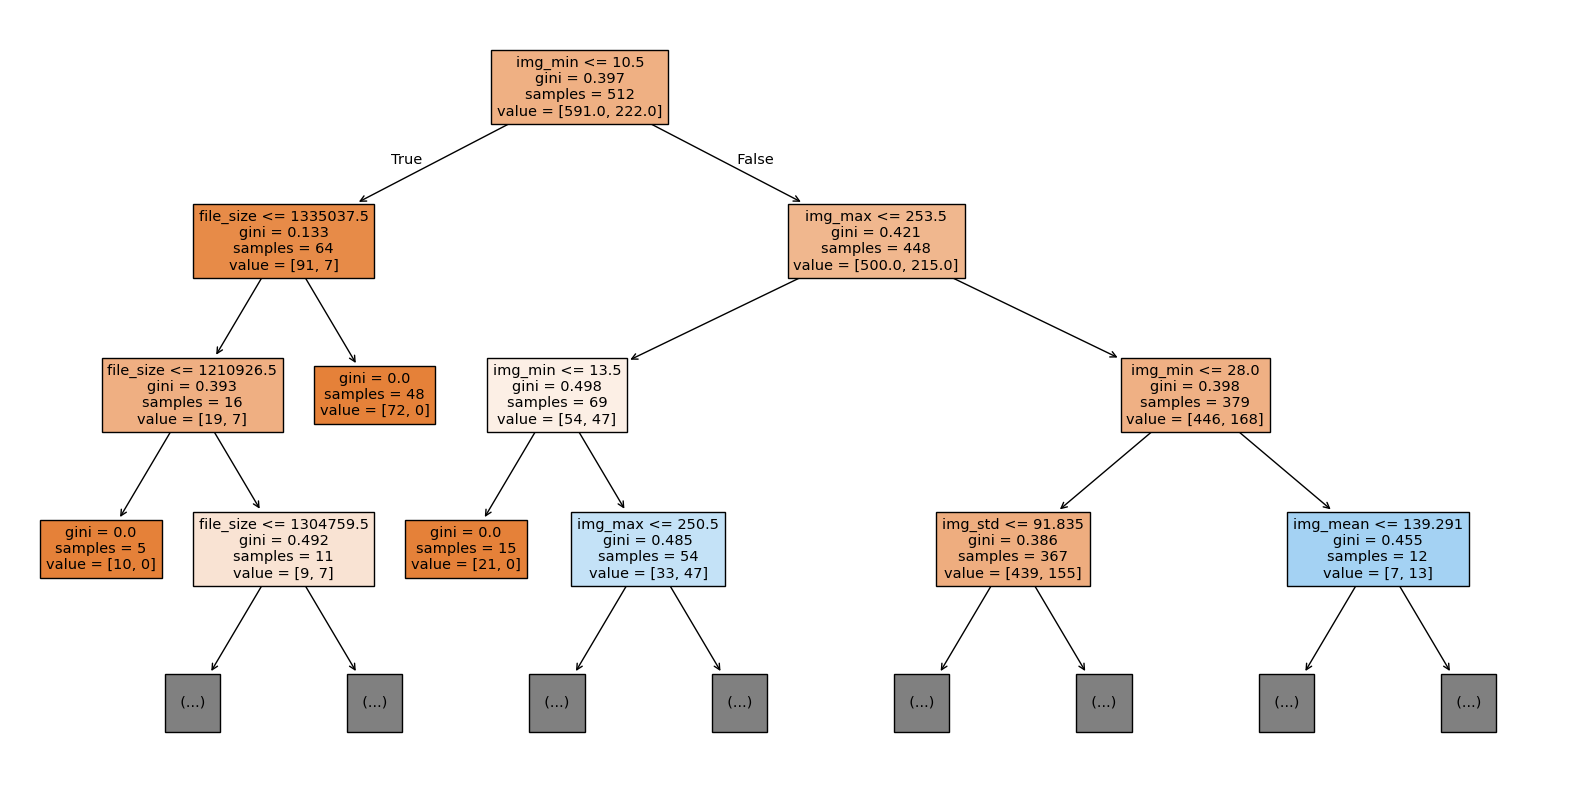

In [10]:
#rf = ensemble.RandomForestClassifier(n_jobs=-1, random_state=321)
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
print(rf.score(X_train, y_train))
y_pred = rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test,y_pred)
displayheatmap(cm)

importances = rf.feature_importances_
#print(importances )
print("Significant features impacting prediction")
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp)

feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = rf.estimators_[0]   # first tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X_train.columns,
    filled=True,
    max_depth=3   # limit depth to keep it readable
)
plt.show()


img_std       0.188684
img_min       0.168143
img_mean      0.121156
file_size     0.108979
img_median    0.056089
img_max       0.013530
dtype: float64


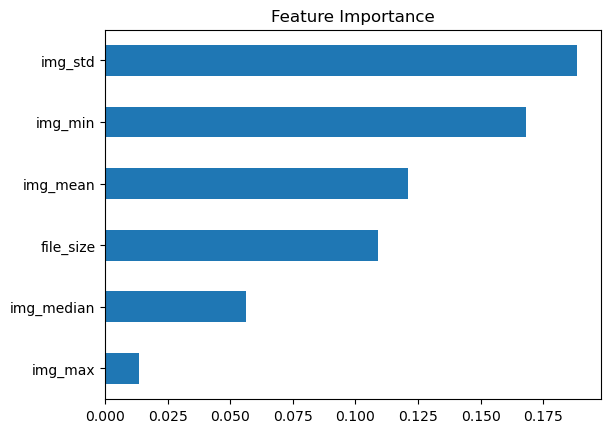

In [9]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    rf, X_train, y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(r.importances_mean, index=X.columns)
perm_imp = perm_imp.sort_values(ascending=False)
print(perm_imp)

perm_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()



In [ ]:
Conclusion:
Training only img_mean and img_std is very fast compared to pixel columns.
Random Forest gives excellent results. It predicts normal and anormal images correctly
SVM is poor performance, it predicted everything as normal
Knn perf not good - Recall negative - 0.26

In [ ]:
Training img_mean,img_std,img_min,img_max,img_median is very fast for 3 models compared to pixel columns.
Random Forest has good perf with accuracy 0.84 and recall negative 0.6
SVM is worst with recall negative 0,  accuracy = 0.74
Knn perf not good - Recall negative - 0.26, accuracy = 0.74

In [ ]:
Training mean,std and skew par channel for 3 objects
Random Forest has good perf with accuracy 0.87 and recall negative 0.58

In [ ]:
Training by file_size, mean per channel,std per channel, skew per channel,img_min,img_max,img_median for full mvtec image dataset
Random Forest has good perf with accuracy 0.87, precision = 0.83 and recall negative 0.61 recall positive = 0.96
XGBoost is good with accuracy 0.85 and recall negative = 0.43, recall positive = 0.98
Knn perf not good - Recall negative - 0.20, accuracy = 0.72
SVM is worst with recall negative 0,  accuracy = 0.76

Predict classes 
RF - 0.9981 ( RF is best)
XGBoost - 0.9968

In [ ]:
Hog features - Not good
RF - Recall negative - 0.33, accuracy = 0.77
KNN, SVM - Recall negative - 0
LBP with RF is better with  Recall negative 0.41 

In [3]:
# Get original or gray images of full dataset
image_files = list(Path(f"../Projects/mvtec_anomaly_detection/").rglob("*"))
#image_files = list(Path(f"C:/Kavitha/DataScientest/Projects/Test").rglob("*"))
#image_files = list(Path(f"C:/Kavitha/DataScientest/Projects/Test_toothbrush").rglob("*"))
image_files = [f for f in image_files if f.is_file() and f.suffix.lower() in ('.png','.jpg','jpeg','.gif') and f.parent.parent.name != 'ground_truth']

#print(len(image_files))
#print(image_files[10])
#print(os.path.dirname(image_files[100]))
#print(os.path.basename(os.path.dirname(image_files[100])))

df = pd.DataFrame({
    "file_path": image_files,
    "category_name": [f.parent.parent.parent.name for f in image_files],
    "dir_name": [f.parent.name for f in image_files],
    "file_name": [f.name for f in image_files],     
    "file_size": [f.stat().st_size for f in image_files],
    "label":  [0 if f.parent.name == "good" else 1 for f in image_files],
    "img": [get_original_image(f) for f in image_files],
})


In [9]:
df.head()
df.to_csv("Data/mvtec_full_images_colour.csv", index=False)
df.to_pickle("Data/mvtec_full_images_colour.pkl")

# Load
#df = pd.read_pickle("mvtec_full_images.pkl")
#df.shape


In [28]:
# Extract stats features of colour images

df['mean'] = [img.mean(axis=(0, 1)) for img in df["img"]]
df['mean_red'] = pd.to_numeric(df['mean'].str[0]).round(2)
df['mean_green'] = pd.to_numeric(df['mean'].str[1]).round(2)
df['mean_blue'] = pd.to_numeric(df['mean'].str[2]).round(2)

df['std'] = [img.std(axis=(0, 1)) for img in df["img"]]
df['std_red'] = pd.to_numeric(df['std'].str[0]).round(2)
df['std_green'] = pd.to_numeric(df['std'].str[1]).round(2)
df['std_blue'] = pd.to_numeric(df['std'].str[2]).round(2)

df['skew'] = [skew(img.flatten()) for img in df["img"]]
df['skew_red'] = [skew(img[:, :, 0].flatten()) for img in df["img"]]

df['skew_green'] = [skew(img[:, :, 1].flatten()) for img in df["img"]]
df['skew_blue'] = [skew(img[:, :, 2].flatten()) for img in df["img"]]

df['img_min'] = [img.min() for img in df["img"]]

df['img_max'] = [img.max() for img in df["img"]]
df['img_median'] = [np.median(img) for img in df["img"]]



In [8]:
# # Extract stats features of gray images
df['mean'] = [img.mean() for img in df["img"]]
df['std'] = [img.std() for img in df["img"]]
df['skew'] = [skew(img.flatten()) for img in df["img"]]
df['median'] = [np.median(img) for img in df["img"]]
df['min'] = [img.min() for img in df["img"]]
df['max'] = [img.max() for img in df["img"]]


In [12]:
#df[df['category_name']=='cable'].head(5)
df.shape

(5354, 13)

In [15]:
#df.to_pickle("mvtec_full_statistiques_features_gray_images.pkl")
#df.to_csv("mvtec_full_statistiques_features_gray_images.csv", index=False)
#df= pd.read_pickle("mvtec_full_statistiques_features_gray_images.pkl")
#print(df.shape)
#df.head(5)
#df_stats.head()
#df.to_pickle("df_colourChannels.pkl")
#df_loaded = pd.read_pickle("df_colourChannels.pkl")
#df.to_csv("df_colourChannels.csv", index=False)

In [16]:
df_loaded = pd.read_pickle("mvtec_full_statistiques_features_gray_images.pkl")
df_loaded.head()

,file_path,category_name,dir_name,file_name,file_size,label,img,mean,std,skew,median,min,max
0,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,000.png,526002,1,"[[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0,...",0.546330,0.357824,0.352307,0.356863,0.113725,1.0
1,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,001.png,525657,1,"[[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0,...",0.532416,0.362055,0.396253,0.337255,0.098039,1.0
2,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,002.png,515614,1,"[[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0,...",0.536583,0.358041,0.406645,0.333333,0.113725,1.0
3,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,003.png,488569,1,"[[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0,...",0.526804,0.368298,0.394503,0.313725,0.109804,1.0
4,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,004.png,549987,1,"[[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0,...",0.544815,0.357150,0.358822,0.356863,0.113725,1.0


In [47]:
X = df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
'''

# Predicting with hog features
X= pd.DataFrame(df['hog'].tolist())
y= df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)

'''
X_train
#df.loc[2851]

,file_size,mean_red,mean_green,mean_blue,std_red,std_green,std_blue,skew_red,skew_green,skew_blue,img_min,img_max,img_median
2851,500236,53.99,59.25,59.52,40.32,46.01,38.84,0.995844,0.942496,1.017493,13,255,31.0
4024,1016652,114.60,121.71,114.56,31.55,35.85,34.47,-0.067401,-0.021978,0.020087,41,242,118.0
2906,491422,52.12,57.00,58.70,37.83,42.87,37.15,0.908104,0.825832,0.860961,13,255,30.0
5196,402687,108.70,108.70,108.70,84.72,84.72,84.72,1.083439,1.083439,1.083439,20,255,68.0
3123,629482,78.97,78.76,85.78,76.14,76.34,70.86,0.435470,0.442229,0.450504,12,216,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,1383122,82.32,105.47,119.78,38.59,54.61,62.08,1.016708,0.767040,0.547834,13,255,93.0
1091,1920541,100.00,94.06,93.47,37.49,36.48,31.65,-0.115186,0.056211,0.000210,14,227,96.0
513,1362331,86.48,108.52,122.48,37.20,51.53,57.14,1.158943,0.919052,0.713832,16,255,96.0
4858,1503990,173.18,119.65,89.84,20.42,17.99,12.84,-0.622186,-0.415457,-0.237171,45,236,122.0


In [48]:
X_test

,file_size,mean_red,mean_green,mean_blue,std_red,std_green,std_blue,skew_red,skew_green,skew_blue,img_min,img_max,img_median
2681,458884,58.95,65.13,63.19,41.67,48.28,38.73,0.727993,0.694552,0.735965,14,255,33.0
1075,1853630,99.40,93.71,93.01,36.94,34.82,30.34,-0.149267,0.015633,-0.044451,15,238,96.0
1273,1819956,94.48,90.25,92.10,35.26,34.15,30.57,-0.190285,-0.007222,-0.068422,13,223,94.0
2178,1236067,69.23,50.19,44.13,54.56,25.44,13.71,0.962119,1.081300,1.088247,23,215,36.0
1558,471495,111.78,111.78,111.78,38.95,38.95,38.95,-0.208398,-0.208398,-0.208398,34,185,118.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3869,407727,183.33,183.33,183.33,32.33,32.33,32.33,-2.028885,-2.028885,-2.028885,37,211,198.0
2165,1245213,63.85,46.59,41.43,52.16,23.89,13.49,1.352947,1.614369,1.612705,22,255,34.0
992,1136611,176.94,168.71,165.82,60.93,66.19,66.91,-1.546843,-1.207225,-1.133272,14,246,199.0
5255,412107,96.79,96.79,96.79,82.81,82.81,82.81,1.330934,1.330934,1.330934,21,255,59.0


0.8066775624562222
0.7236227824463118
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       819
           1       0.35      0.20      0.25       252

    accuracy                           0.72      1071
   macro avg       0.56      0.54      0.54      1071
weighted avg       0.68      0.72      0.69      1071



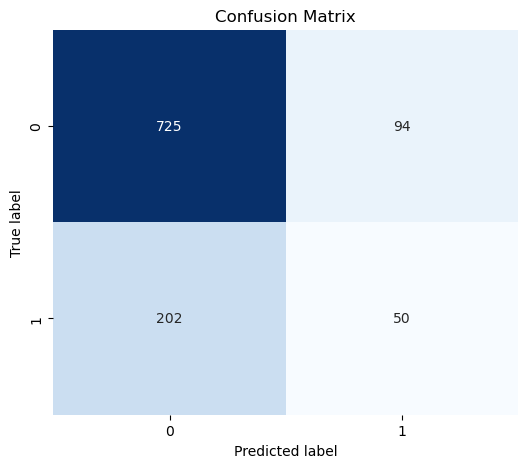

In [45]:
#knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski')
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print(knn.score(X_train, y_train))
y_pred = knn.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
#print(classification_report_imbalanced(y_test, y_pred))
cm= confusion_matrix(y_test,y_pred)
displayheatmap(cm)

0.7651179080084053
0.7647058823529411
              precision    recall  f1-score   support

           0       0.76      1.00      0.87       819
           1       0.00      0.00      0.00       252

    accuracy                           0.76      1071
   macro avg       0.38      0.50      0.43      1071
weighted avg       0.58      0.76      0.66      1071



C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

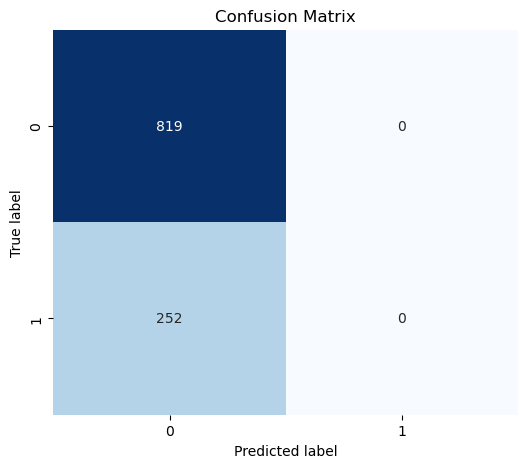

In [47]:
svm = SVC()
svm.fit(X_train, y_train)
print(svm.score(X_train, y_train))
y_pred = svm.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test,y_pred)
displayheatmap(cm)

1.0
0.8776844070961718
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       819
           1       0.83      0.61      0.70       252

    accuracy                           0.88      1071
   macro avg       0.86      0.78      0.81      1071
weighted avg       0.87      0.88      0.87      1071



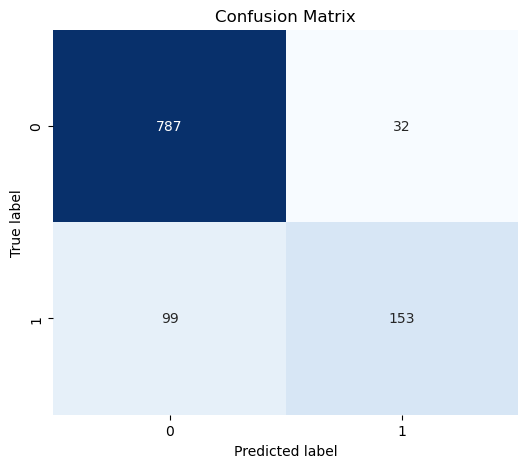

Significant features impacting prediction
mean_blue     0.089388
file_size     0.089249
img_min       0.086922
std_blue      0.083990
skew_blue     0.079035
mean_green    0.075233
mean_red      0.074030
std_green     0.073796
std_red       0.073041
skew_green    0.071696
skew_red      0.070513
img_median    0.067711
img_max       0.065395
dtype: float64


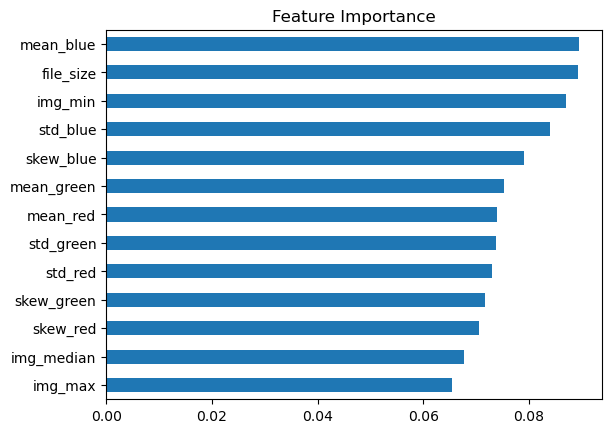

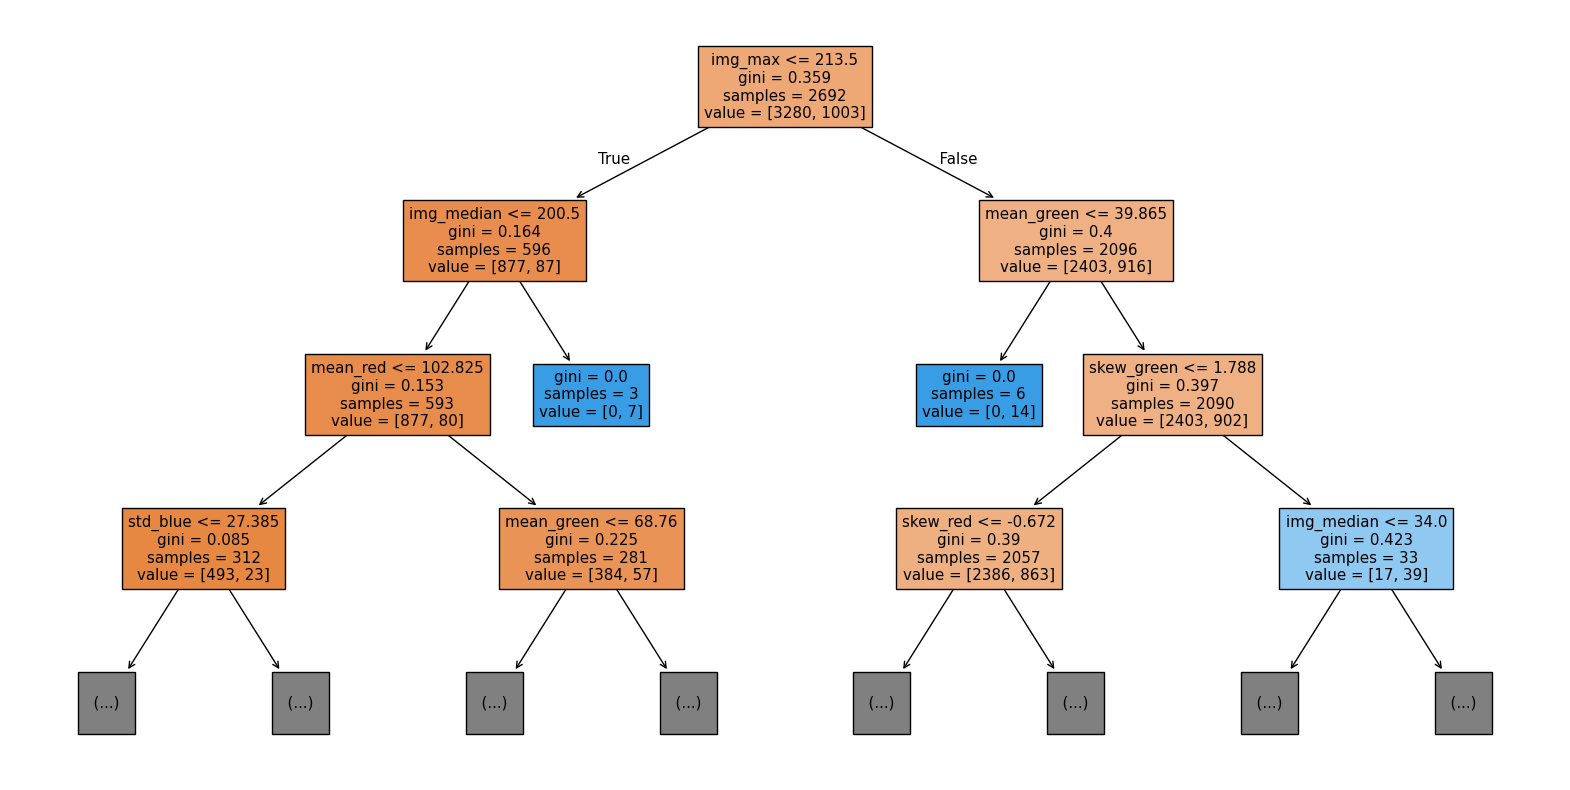

In [49]:
#rf = ensemble.RandomForestClassifier(n_jobs=-1, random_state=321)
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
print(rf.score(X_train, y_train))
y_pred = rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test,y_pred)
displayheatmap(cm)

importances = rf.feature_importances_
#print(importances )
print("Significant features impacting prediction")
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp)

feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

tree = rf.estimators_[0]   # first tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X_train.columns,
    filled=True,
    max_depth=3   # limit depth to keep it readable
)
plt.show()


In [90]:

image_files = list(Path(f"C:/Kavitha/DataScientest/Projects/Predict_Images").rglob("*"))
image_files = [f for f in image_files if f.is_file() and f.suffix.lower() in ('.png','.jpg','jpeg','.gif') and f.parent.parent.name != 'ground_truth']
df_predict = pd.DataFrame({
    "file_path": image_files,
    "category_name": [f.parent.parent.parent.name for f in image_files],
    "dir_name": [f.parent.name for f in image_files],
    "file_name": [f.name for f in image_files],     
    "file_size": [f.stat().st_size for f in image_files],
    "label":  [0 if f.parent.name == "good" else 1 for f in image_files],
    "img": [get_original_image(f) for f in image_files],
})
df_predict['mean'] = [img.mean(axis=(0, 1)) for img in df_predict["img"]]
df_predict['mean_red'] = pd.to_numeric(df_predict['mean'].str[0]).round(2)
df_predict['mean_green'] = pd.to_numeric(df_predict['mean'].str[1]).round(2)
df_predict['mean_blue'] = pd.to_numeric(df_predict['mean'].str[2]).round(2)

df_predict['std'] = [img.std(axis=(0, 1)) for img in df_predict["img"]]
df_predict['std_red'] = pd.to_numeric(df_predict['std'].str[0]).round(2)
df_predict['std_green'] = pd.to_numeric(df_predict['std'].str[1]).round(2)
df_predict['std_blue'] = pd.to_numeric(df_predict['std'].str[2]).round(2)

df_predict['skew'] = [skew(img.flatten()) for img in df_predict["img"]]
df_predict['skew_red'] = [skew(img[:, :, 0].flatten()) for img in df_predict["img"]]

df_predict['skew_green'] = [skew(img[:, :, 1].flatten()) for img in df_predict["img"]]
df_predict['skew_blue'] = [skew(img[:, :, 2].flatten()) for img in df_predict["img"]]

df_predict['img_min'] = [img.min() for img in df_predict["img"]]

df_predict['img_max'] = [img.max() for img in df_predict["img"]]
df_predict['img_median'] = [np.median(img) for img in df_predict["img"]]



X_df_predict = df_predict.select_dtypes(include='number')
X_df_predict = X_df_predict.drop(['label','skew'], axis=1)


y_pred = rf.predict(X_df_predict)


print(y_pred)

print(df_predict)


[1 0 0 0 1 1 0 0 1 1 1 1 0 0]
                                            file_path category_name  \
0   C:\Kavitha\DataScientest\Projects\Predict_Imag...        bottle   
1   C:\Kavitha\DataScientest\Projects\Predict_Imag...        bottle   
2   C:\Kavitha\DataScientest\Projects\Predict_Imag...        bottle   
3   C:\Kavitha\DataScientest\Projects\Predict_Imag...        bottle   
4   C:\Kavitha\DataScientest\Projects\Predict_Imag...         cable   
5   C:\Kavitha\DataScientest\Projects\Predict_Imag...         cable   
6   C:\Kavitha\DataScientest\Projects\Predict_Imag...         cable   
7   C:\Kavitha\DataScientest\Projects\Predict_Imag...         cable   
8   C:\Kavitha\DataScientest\Projects\Predict_Imag...          pill   
9   C:\Kavitha\DataScientest\Projects\Predict_Imag...          pill   
10  C:\Kavitha\DataScientest\Projects\Predict_Imag...          pill   
11  C:\Kavitha\DataScientest\Projects\Predict_Imag...          pill   
12  C:\Kavitha\DataScientest\Projects\Predict_I

In [53]:
X = df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= df['category_name']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
y_train
#df.loc[3159]

3159          pill
2133      hazelnut
2769     metal_nut
5005        zipper
1809      hazelnut
           ...    
3895          tile
3120          pill
1191        carpet
4225    toothbrush
5142        zipper
Name: category_name, Length: 4283, dtype: object

1.0
0.9981325863678805
              precision    recall  f1-score   support

      bottle       1.00      1.00      1.00        58
       cable       1.00      1.00      1.00        75
     capsule       1.00      1.00      1.00        70
      carpet       1.00      1.00      1.00        80
        grid       1.00      1.00      1.00        68
    hazelnut       1.00      1.00      1.00       100
     leather       1.00      1.00      1.00        74
   metal_nut       1.00      1.00      1.00        67
        pill       1.00      1.00      1.00        87
       screw       1.00      1.00      1.00        96
        tile       0.97      1.00      0.99        70
  toothbrush       1.00      1.00      1.00        20
  transistor       1.00      0.97      0.98        63
        wood       1.00      1.00      1.00        65
      zipper       1.00      1.00      1.00        78

    accuracy                           1.00      1071
   macro avg       1.00      1.00      1.00      1071
wei

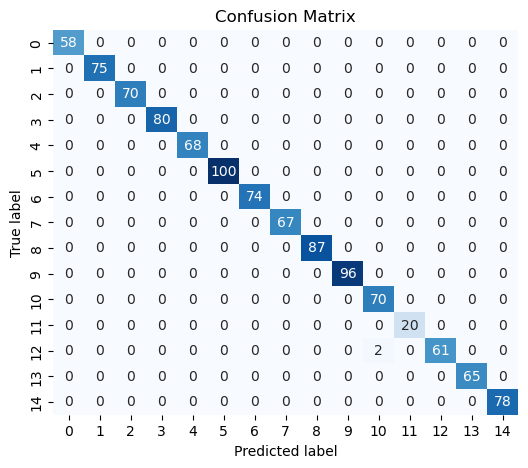

Significant features impacting prediction
file_size     0.171495
mean_blue     0.114024
img_median    0.088963
std_blue      0.082623
mean_green    0.082431
skew_red      0.077738
mean_red      0.073610
std_red       0.068043
std_green     0.067155
skew_green    0.064276
skew_blue     0.057486
img_min       0.040106
img_max       0.012049
dtype: float64


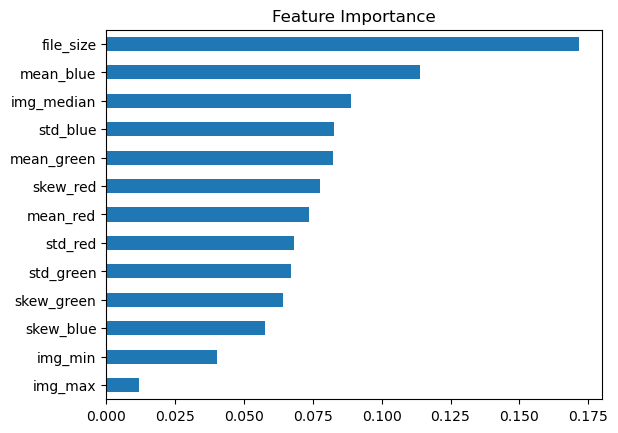

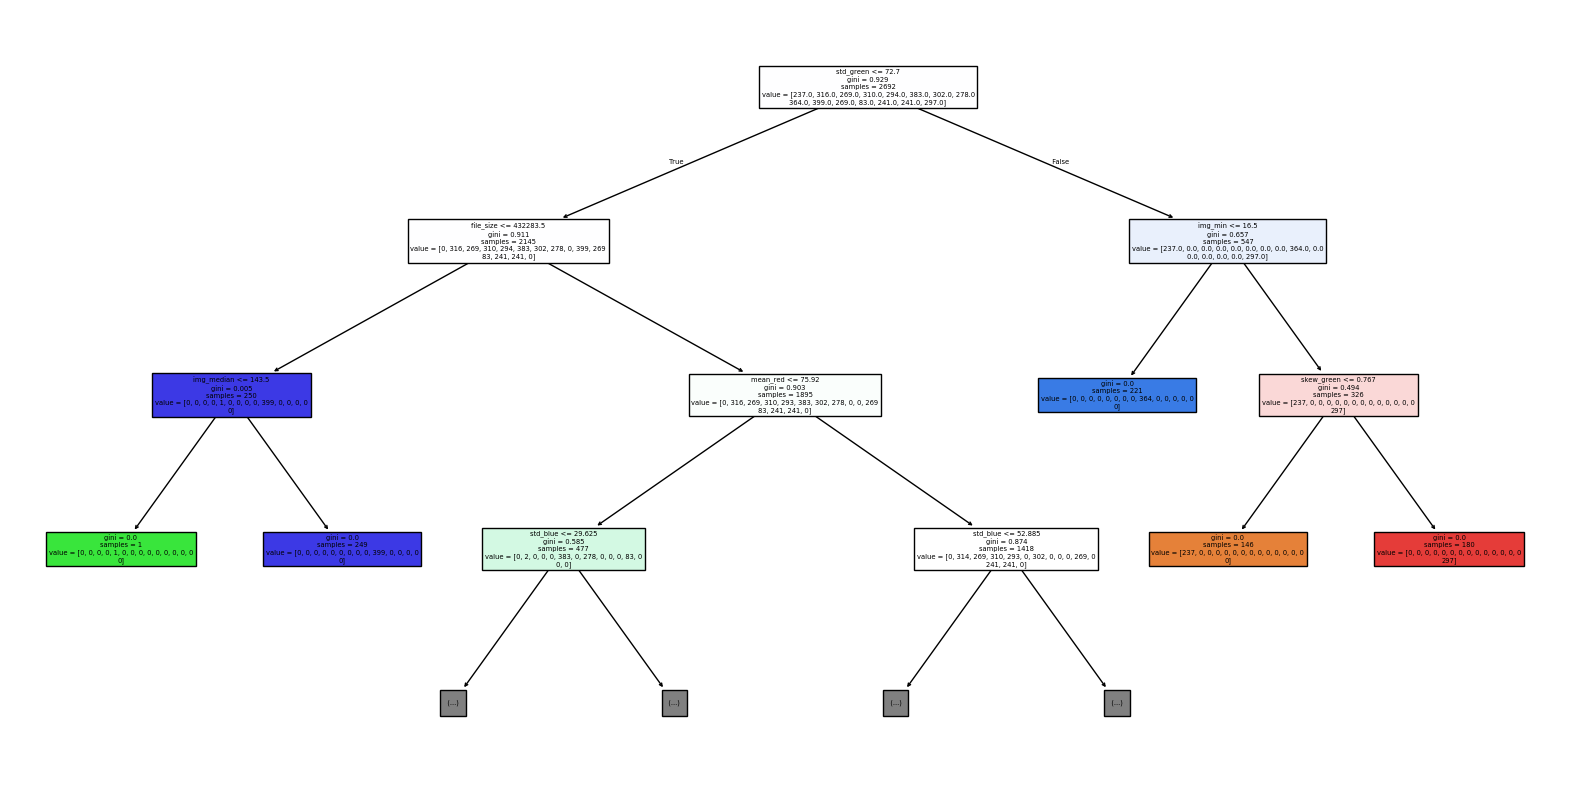

In [54]:
#rf = ensemble.RandomForestClassifier(n_jobs=-1, random_state=321)
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
print(rf.score(X_train, y_train))
y_pred = rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test,y_pred)
displayheatmap(cm)

importances = rf.feature_importances_
#print(importances )
print("Significant features impacting prediction")
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp)

feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

tree = rf.estimators_[0]   # first tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X_train.columns,
    filled=True,
    max_depth=3   # limit depth to keep it readable
)
plt.show()


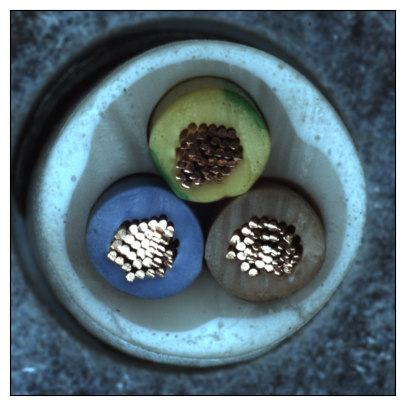

[ 76.24067211  97.35847473 106.47094631]
[42.68490088 56.32426639 62.27088992]
106.47094631195068


In [14]:
image = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection/cable/train/good/000.png"
img = cv2.imread(image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize = (8,5))
plt.imshow(img)
plt.xticks([])
plt.yticks([])

plt.show();
print(img.mean(axis=(0,1)))
print(img.std(axis=(0,1)))
mean = img.mean(axis=(0,1))
print(mean[2])


(5354, 22)
[0]	train-logloss:0.41832	eval-logloss:0.49051
[1]	train-logloss:0.35260	eval-logloss:0.43298
[2]	train-logloss:0.30539	eval-logloss:0.40947
[3]	train-logloss:0.28263	eval-logloss:0.40594
[4]	train-logloss:0.26050	eval-logloss:0.39707
[5]	train-logloss:0.24049	eval-logloss:0.38352
[6]	train-logloss:0.22223	eval-logloss:0.37941
[7]	train-logloss:0.21086	eval-logloss:0.37821
[8]	train-logloss:0.19951	eval-logloss:0.38126
[9]	train-logloss:0.18950	eval-logloss:0.37592
[10]	train-logloss:0.17537	eval-logloss:0.38174
[11]	train-logloss:0.16031	eval-logloss:0.38003
[12]	train-logloss:0.14910	eval-logloss:0.37226
[13]	train-logloss:0.14227	eval-logloss:0.37424
[14]	train-logloss:0.13533	eval-logloss:0.37736
[15]	train-logloss:0.12609	eval-logloss:0.37156
[16]	train-logloss:0.12134	eval-logloss:0.37463
[17]	train-logloss:0.11191	eval-logloss:0.37703
[18]	train-logloss:0.11064	eval-logloss:0.37606
[19]	train-logloss:0.10351	eval-logloss:0.37831
[20]	train-logloss:0.09906	eval-logloss

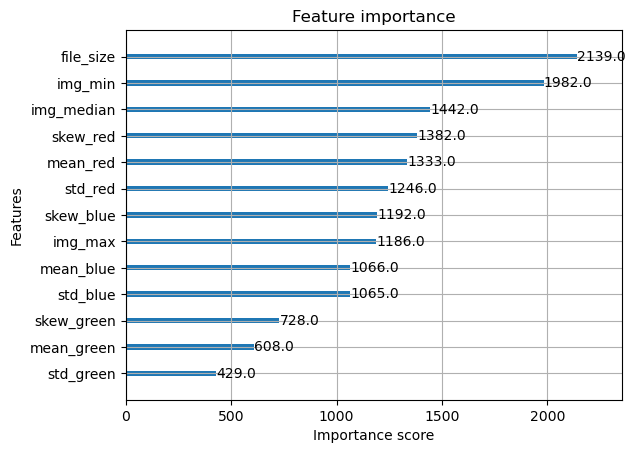

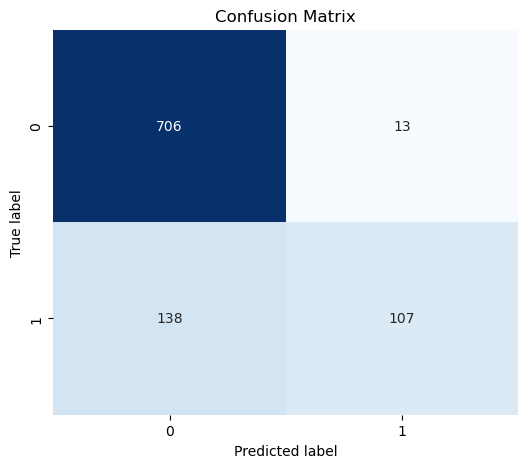

'[0]\teval-logloss:0.35356126167459795'

In [43]:
# XG Boost - Predict anamoly
#df= pd.read_pickle("mvtec_full_statistiques_features.pkl")
print(df.shape)

X = df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y= df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
X, X_valid, y, y_valid = train_test_split(X, y, test_size=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
train = xgb.DMatrix(data=X_train, label=y_train)
test = xgb.DMatrix(data=X_test, label=y_test)
valid = xgb.DMatrix(data=X_valid, label=y_valid)
params = {'booster': 'gbtree', 'learning_rate': 1, 'objective': 'binary:logistic'}

xgb1 = xgb.train(params=params, dtrain=train, num_boost_round=100, evals=[(train, 'train'), (test, 'eval')])

params = {'booster': 'gbtree', 'learning_rate': 0.01, 'objective': 'binary:logistic'}

xgb2 = xgb.train(params=params, dtrain=train, num_boost_round=700, evals=[(train, 'train'), (test, 'eval')])

xgb.plot_importance(xgb2, max_num_features=15);

types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

#for f in types:
#    xgb.plot_importance(xgb2 ,max_num_features=15, importance_type=f, title='importance: '+f);

bst_cv = xgb.cv(params=params,
                dtrain=train,
                num_boost_round=100,
                nfold=3,
                early_stopping_rounds=60)
bst_cv

preds = xgb2.predict(test)
xgbpreds = pd.Series(np.where(preds > 0.5, 1, 0))
pd.crosstab(xgbpreds, pd.Series(y_test))

#y_pred = xgb2.predict(test)
print(accuracy_score(pd.Series(y_test), xgbpreds))
print(classification_report(pd.Series(y_test), xgbpreds))
cm= confusion_matrix(pd.Series(y_test),xgbpreds)
displayheatmap(cm)

xgb2.eval(test)


0.9968879668049793
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        61
           2       1.00      0.97      0.99        68
           3       1.00      1.00      1.00        85
           4       1.00      1.00      1.00        57
           5       1.00      1.00      1.00        94
           6       1.00      0.99      0.99        69
           7       1.00      1.00      1.00        53
           8       1.00      1.00      1.00        63
           9       1.00      1.00      1.00        87
          10       0.99      1.00      0.99        76
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        43
          13       0.97      1.00      0.99        70
          14       1.00      1.00      1.00        72

    accuracy                           1.00       964
   macro avg       1.00      1.00      1.00       964
weighte

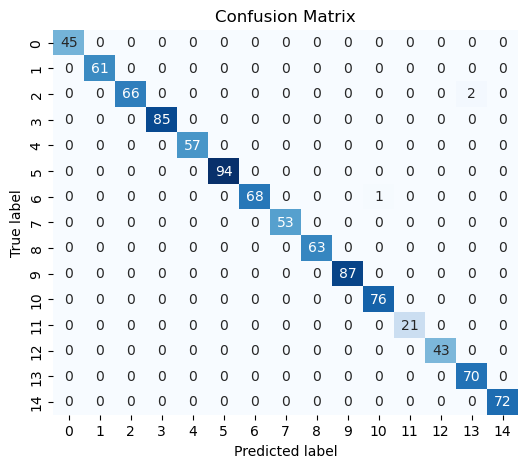

'[0]\teval-mlogloss:0.01526475845980052'

In [45]:
# XG Boost - Predict classes
#df= pd.read_pickle("mvtec_full_statistiques_features.pkl")
'''
print(df.shape)
X = df.select_dtypes(include='number')
X= X.drop(['label','skew'], axis=1)
y_cat= df['category_name']
le = LabelEncoder()
y = le.fit_transform(y_cat)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # reproducible split
    stratify=y        # preserves class distribution
)
print(y_train)
print(le.classes_)

X, X_valid, y, y_valid = train_test_split(X, y, test_size=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
train = xgb.DMatrix(data=X_train, label=y_train)
test = xgb.DMatrix(data=X_test, label=y_test)
valid = xgb.DMatrix(data=X_valid, label=y_valid)
train
#params = {'booster': 'gbtree', 'learning_rate': 1, 'objective': 'multi:softprob'}

#xgb1 = xgb.train(params=params, dtrain=train, num_boost_round=100, evals=[(train, 'train'), (test, 'eval')])

params = {'booster': 'gbtree', 'learning_rate': 0.01, 'objective': 'multi:softprob',  'num_class' :15}

xgb2 = xgb.train(params=params, dtrain=train, num_boost_round=700, evals=[(train, 'train'), (test, 'eval')])

xgb.plot_importance(xgb2, max_num_features=15);

types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

#for f in types:
#    xgb.plot_importance(xgb2 ,max_num_features=15, importance_type=f, title='importance: '+f);

bst_cv = xgb.cv(params=params,
                dtrain=train,
                num_boost_round=100,
                nfold=3,
                early_stopping_rounds=60)
bst_cv
'''
preds = xgb2.predict(test)
xgbpreds = np.argmax(preds, axis=1)
pd.crosstab(xgbpreds, pd.Series(y_test))

#y_pred = xgb2.predict(test)
print(accuracy_score(pd.Series(y_test), xgbpreds))
print(classification_report(pd.Series(y_test), xgbpreds))
cm= confusion_matrix(pd.Series(y_test),xgbpreds)
displayheatmap(cm)

xgb2.eval(test)


In [7]:
train = xgb.DMatrix(data=X_train, label=y_train)
test = xgb.DMatrix(data=X_test, label=y_test)
valid = xgb.DMatrix(data=X_valid, label=y_valid)
params = {'booster': 'gbtree', 'learning_rate': 1, 'objective': 'binary:logistic'}

xgb1 = xgb.train(params=params, dtrain=train, num_boost_round=100, evals=[(train, 'train'), (test, 'eval')])


[0]	train-logloss:0.41091	eval-logloss:0.44598
[1]	train-logloss:0.36847	eval-logloss:0.41642
[2]	train-logloss:0.31231	eval-logloss:0.38279
[3]	train-logloss:0.27846	eval-logloss:0.37232
[4]	train-logloss:0.24612	eval-logloss:0.35809
[5]	train-logloss:0.22033	eval-logloss:0.34604
[6]	train-logloss:0.20967	eval-logloss:0.34513
[7]	train-logloss:0.19375	eval-logloss:0.33448
[8]	train-logloss:0.17392	eval-logloss:0.32924
[9]	train-logloss:0.16802	eval-logloss:0.32678
[10]	train-logloss:0.16206	eval-logloss:0.32362
[11]	train-logloss:0.15342	eval-logloss:0.32305
[12]	train-logloss:0.14866	eval-logloss:0.32005
[13]	train-logloss:0.14315	eval-logloss:0.32491
[14]	train-logloss:0.13623	eval-logloss:0.32959
[15]	train-logloss:0.12519	eval-logloss:0.32675
[16]	train-logloss:0.12014	eval-logloss:0.32424
[17]	train-logloss:0.11542	eval-logloss:0.32579
[18]	train-logloss:0.11228	eval-logloss:0.32474
[19]	train-logloss:0.10777	eval-logloss:0.32157
[20]	train-logloss:0.10365	eval-logloss:0.32430
[2

In [8]:
params = {'booster': 'gbtree', 'learning_rate': 0.01, 'objective': 'binary:logistic'}

xgb2 = xgb.train(params=params, dtrain=train, num_boost_round=700, evals=[(train, 'train'), (test, 'eval')])

[0]	train-logloss:0.54210	eval-logloss:0.54127
[1]	train-logloss:0.53954	eval-logloss:0.53921
[2]	train-logloss:0.53704	eval-logloss:0.53720
[3]	train-logloss:0.53460	eval-logloss:0.53529
[4]	train-logloss:0.53221	eval-logloss:0.53340
[5]	train-logloss:0.52987	eval-logloss:0.53152
[6]	train-logloss:0.52759	eval-logloss:0.52967
[7]	train-logloss:0.52536	eval-logloss:0.52790
[8]	train-logloss:0.52317	eval-logloss:0.52619
[9]	train-logloss:0.52103	eval-logloss:0.52458
[10]	train-logloss:0.51893	eval-logloss:0.52289
[11]	train-logloss:0.51688	eval-logloss:0.52132
[12]	train-logloss:0.51487	eval-logloss:0.51971
[13]	train-logloss:0.51290	eval-logloss:0.51823
[14]	train-logloss:0.51097	eval-logloss:0.51669
[15]	train-logloss:0.50898	eval-logloss:0.51514
[16]	train-logloss:0.50722	eval-logloss:0.51363
[17]	train-logloss:0.50550	eval-logloss:0.51219
[18]	train-logloss:0.50368	eval-logloss:0.51068
[19]	train-logloss:0.50173	eval-logloss:0.50900
[20]	train-logloss:0.49988	eval-logloss:0.50753
[2

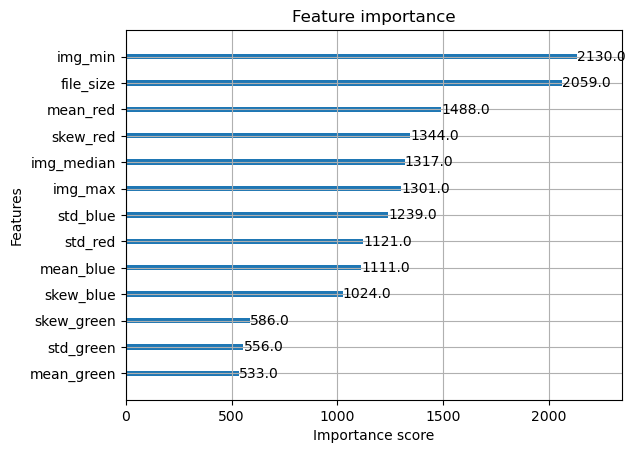

In [9]:
xgb.plot_importance(xgb2, max_num_features=15);

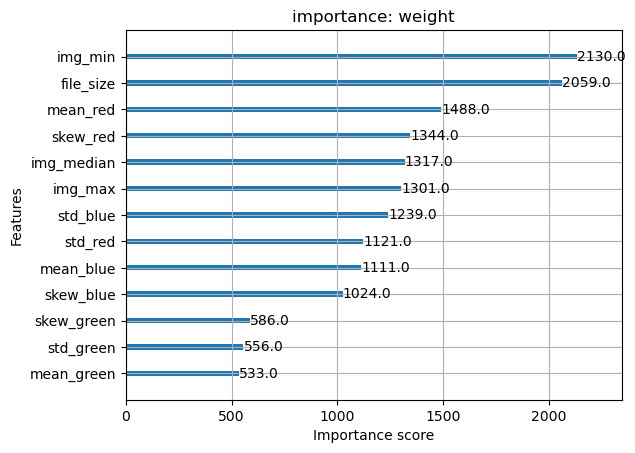

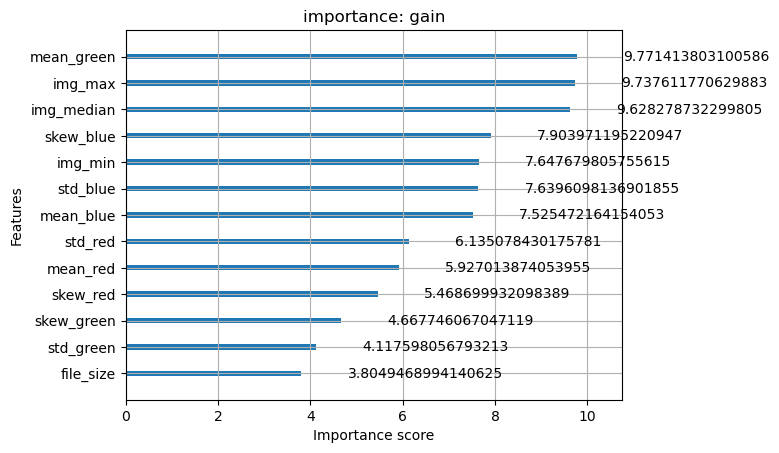

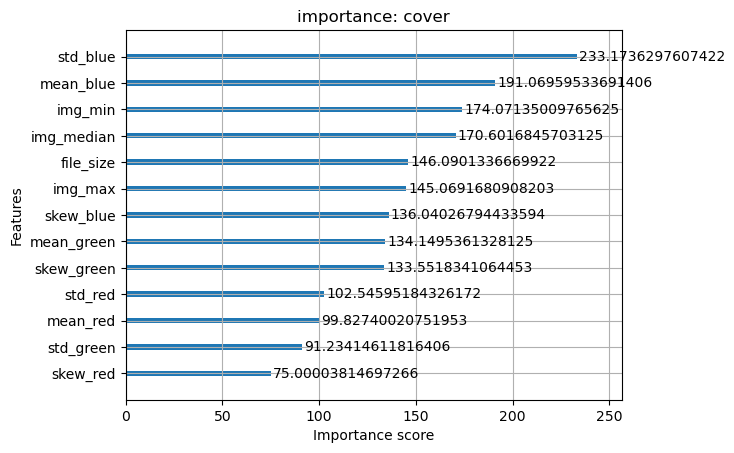

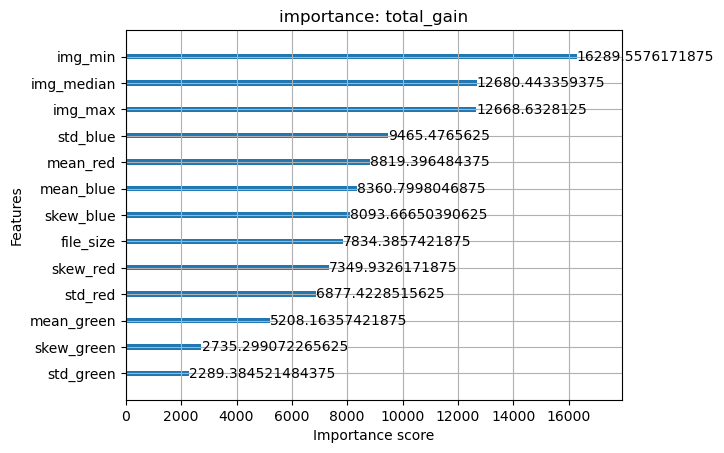

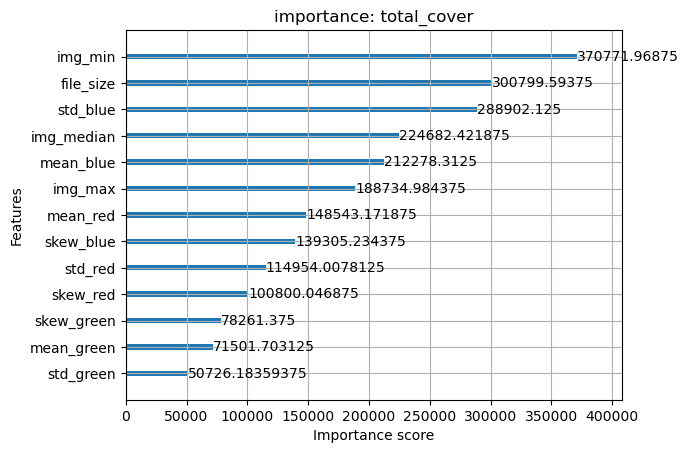

In [10]:
types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

for f in types:
    xgb.plot_importance(xgb2 ,max_num_features=15, importance_type=f, title='importance: '+f);


In [11]:
bst_cv = xgb.cv(params=params,
                dtrain=train,
                num_boost_round=100,
                nfold=3,
                early_stopping_rounds=60)
bst_cv


,train-logloss-mean,train-logloss-std,test-logloss-mean,test-logloss-std
0,0.541998,0.004858,0.542950,0.009402
1,0.539317,0.004894,0.540967,0.009325
2,0.536675,0.004932,0.539032,0.009246
3,0.534095,0.004981,0.537132,0.009203
4,0.531594,0.005009,0.535303,0.009133
...,...,...,...,...
95,0.415787,0.005268,0.449126,0.010160
96,0.415147,0.005291,0.448741,0.010240
97,0.414685,0.005224,0.448355,0.010335
98,0.414001,0.005320,0.447835,0.010313


0.8485477178423236
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       739
           1       0.85      0.43      0.57       225

    accuracy                           0.85       964
   macro avg       0.85      0.70      0.74       964
weighted avg       0.85      0.85      0.83       964



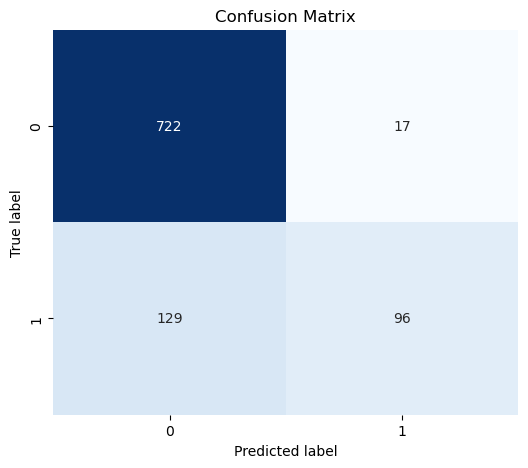

In [15]:
preds = xgb2.predict(test)
xgbpreds = pd.Series(np.where(preds > 0.5, 1, 0))
pd.crosstab(xgbpreds, pd.Series(y_test))

#y_pred = xgb2.predict(test)
print(accuracy_score(pd.Series(y_test), xgbpreds))
print(classification_report(pd.Series(y_test), xgbpreds))
cm= confusion_matrix(pd.Series(y_test),xgbpreds)
displayheatmap(cm)


In [13]:
xgb2.eval(test)


'[0]\teval-logloss:0.33858470279767844'